
# How well do jobs and skills pay for Data Analysts?

### Methology

1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for data analysts
3. Visualize for highest paying skills and most demanded skills

In [2]:
import numpy as np
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_CH = df[(df['job_country'] == 'Switzerland')].dropna(subset=['salary_year_avg'])

In [4]:
job_titles = df_CH['job_title_short'].value_counts().index[:6].tolist()
job_titles

['Data Scientist',
 'Data Engineer',
 'Data Analyst',
 'Machine Learning Engineer',
 'Senior Data Scientist',
 'Software Engineer']

In [5]:
df_CH_top6 = df_CH[df_CH['job_title_short'].isin(job_titles)]

In [6]:
job_order = df_CH_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

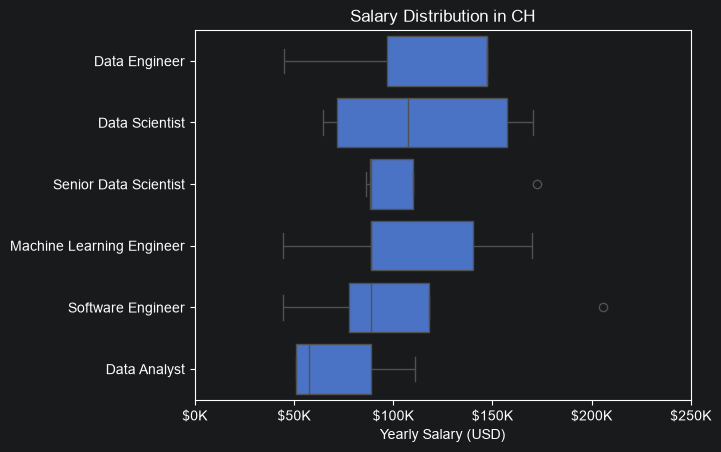

In [7]:
sns.boxplot(data=df_CH_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style="ticks")

plt.title('Salary Distribution in CH')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim([0,250000])
ticks_x = plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

# Investigate Median Salary vs. Skill for Data Analysts

In [10]:
df_CH_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Switzerland')].copy()

df_CH_DA = df_CH_DA.dropna(subset=['salary_year_avg'])

In [11]:
df_CH_DA_explode = df_CH_DA.explode('job_skills')

In [20]:
df_CH_DA_top_pay = df_CH_DA_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_CH_DA_top_pay = df_CH_DA_top_pay.head(10)

df_CH_DA_top_pay

,count,median
job_skills,,
power bi,2,100137.5
python,1,89100.0
gcp,1,72900.0
linux,1,57500.0
looker,1,57500.0
r,1,57500.0
windows,1,57500.0
sql,1,56700.0
elasticsearch,1,51014.0


In [22]:
df_DA_skills = df_CH_DA_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

df_DA_skills

,count,median
job_skills,,
power bi,2,100137.5
python,1,89100.0
gcp,1,72900.0
r,1,57500.0
linux,1,57500.0
looker,1,57500.0
kubernetes,1,51014.0
elasticsearch,1,51014.0
kafka,1,51014.0


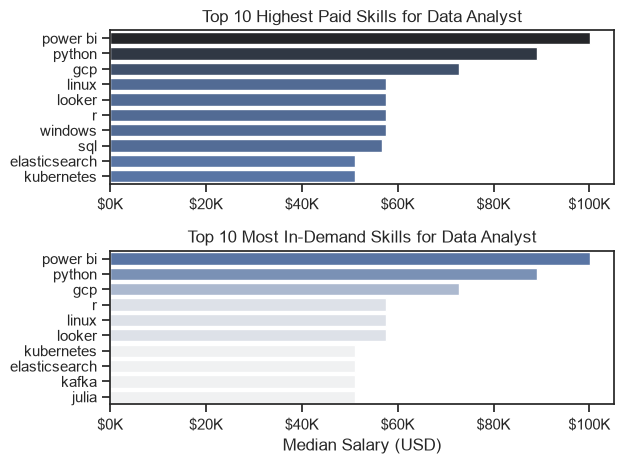

In [25]:
fig, ax = plt.subplots(2, 1)

sns.set_theme(style='ticks')

sns.barplot(data=df_CH_DA_top_pay, x='median', y=df_CH_DA_top_pay.index ,ax=ax[0], hue='median', palette='dark:b_r')

#df_DA_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].legend().remove()
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index ,ax=ax[1], hue='median', palette='light:b')
#df_DA_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].legend().remove()
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()